In [10]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
prash4nt_delhi_sldc_load_data_5_min_resolution_path = kagglehub.dataset_download('prash4nt/delhi-sldc-load-data-5-min-resolution')

print('Data source import complete.')

Using Colab cache for faster access to the 'delhi-sldc-load-data-5-min-resolution' dataset.
Data source import complete.


In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [12]:
!mkdir ./plots

mkdir: cannot create directory ‘./plots’: File exists


# 1. Data Loading & Initial Inspection

In [13]:
import os
# Use the path provided by kagglehub
csv_path = os.path.join(prash4nt_delhi_sldc_load_data_5_min_resolution_path, 'load_data.csv')
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns}")
print(f"\nFirst few rows:")
display(df.head(5))
print(f"\nData Types:")
print(df.dtypes)
print(f"\nBasic Statistics:")
display(df.describe())


Dataset Shape: (293184, 2)
Columns: Index(['timestamp', 'load_MW'], dtype='object')

First few rows:


,timestamp,load_MW
0,2023-04-01 00:00:00,2247.59
1,2023-04-01 00:05:00,2242.49
2,2023-04-01 00:10:00,2215.63
3,2023-04-01 00:15:00,2201.72
4,2023-04-01 00:20:00,2198.52



Data Types:
timestamp     object
load_MW      float64
dtype: object

Basic Statistics:


,load_MW
count,285252.000000
mean,4319.568682
std,1319.479976
min,1450.400000
25%,3416.597500
50%,4253.175000
75%,5303.470000
max,8631.530000


# 2. Data Cleaning & Preprocessing

In [14]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [15]:
# checking for missing, duplicates and negatives
print(f"Missing Values:")
print(df.isna().sum())
print(f"\nMissing Percentage:")
print(df.isna().sum()/len(df)*100)

duplicates = df.duplicated(subset=['timestamp']).sum()
print(f"\nDuplicate timestamps: {duplicates}")

negative_values = (df['load_MW'].dropna() <= 0).sum()
print(f"\nNegative or zero values: {negative_values}")

Missing Values:
timestamp       0
load_MW      7932
dtype: int64

Missing Percentage:
timestamp    0.000000
load_MW      2.705468
dtype: float64

Duplicate timestamps: 0

Negative or zero values: 0


In [16]:
# Detailed Missing Values Analysis
import pandas as pd

# Re-initializing df_cpy and necessary features for this cell to run standalone
df_cpy = df.copy()
df_cpy['timestamp'] = pd.to_datetime(df_cpy['timestamp'])
df_cpy = df_cpy.sort_values('timestamp').reset_index(drop=True)
df_cpy.set_index('timestamp', inplace=True)

# Feature engineering for 'year', 'hour' and 'time_of_day' as used in this cell
df_cpy['year'] = df_cpy.index.year
df_cpy['hour'] = df_cpy.index.hour # hour is needed for categorize_time

def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_cpy['time_of_day'] = df_cpy['hour'].apply(categorize_time)

missing_count = df_cpy['load_MW'].isna().sum()
total_count = len(df_cpy)
missing_percent = (missing_count / total_count) * 100

print("=== Overall Missing Values ===")
print(f"Total Data Points: {total_count:,}")
print(f"Missing 'load_MW' entries: {missing_count:,}")
print(f"Percentage missing: {missing_percent:.2f}%")
print(f"Missing 'timestamp' entries: {df_cpy.index.isna().sum()}")

print("\n=== Missing Values by Year ===")
missing_by_year = df_cpy[df_cpy['load_MW'].isna()].groupby('year').size()
total_by_year = df_cpy.groupby('year').size()
year_summary = pd.DataFrame({'Missing': missing_by_year, 'Total': total_by_year}).fillna(0)
year_summary['% Missing'] = (year_summary['Missing'] / total_by_year * 100).round(2)
display(year_summary)

print("\n=== Missing Values by Time of Day ===")
missing_by_tod = df_cpy[df_cpy['load_MW'].isna()].groupby('time_of_day').size()
tod_summary = pd.DataFrame({'Missing Entries': missing_by_tod})
display(tod_summary)

# Identifying the largest continuous gap
is_na = df_cpy['load_MW'].isna()
gaps = is_na.groupby((is_na != is_na.shift()).cumsum()).transform('size') * is_na
max_gap = gaps.max()
print(f"\nLargest continuous missing data gap: {max_gap} steps ({(max_gap * 5) / 60:.2f} hours)")

=== Overall Missing Values ===
Total Data Points: 293,184
Missing 'load_MW' entries: 7,932
Percentage missing: 2.71%
Missing 'timestamp' entries: 0

=== Missing Values by Year ===


,Missing,Total,% Missing
year,,,
2023,1956,79200,2.47
2024,4173,105408,3.96
2025,1402,105120,1.33
2026,401,3456,11.60



=== Missing Values by Time of Day ===


,Missing Entries
time_of_day,
Afternoon,766
Evening,1006
Morning,269
Night,5891



Largest continuous missing data gap: 590 steps (49.17 hours)


### 2.1 Data Treatment & Imputation Summary

Based on the initial inspection and cleaning steps, the following treatments were applied to the dataset:

*   **Numeric Variables (`load_MW`):**
    *   **Treatment:** **Forward Fill (`ffill`)**.
    *   **Reasoning:** Given that the data has a 5-minute resolution and a strong temporal correlation (autocorrelation), forward filling is appropriate for smaller gaps as the load is unlikely to change drastically in such a short window. For the seasonal decomposition and stationarity tests, we also utilized **Mean Imputation** on resampled daily data to ensure a continuous series.
*   **Categorical Variables (`season`, `time_of_day`, `day_name`):**
    *   **Treatment:** **Feature Engineering / Deterministic Mapping**.
    *   **Reasoning:** These were not imputed but rather derived directly from the `timestamp` index. This ensures 100% consistency and zero missing values for temporal categories.
*   **Timestamps with no valid readings:**
    *   **Treatment:** **Flagged and Preserved**.
    *   **Reasoning:** The analysis checked for irregular gaps using `diff()` and found 0 irregular gaps, meaning the timeline is complete. Missing values in `load_MW` were kept as `NaN` during distribution analysis and filled only for specific statistical tests (like ADF) to maintain the integrity of the time-series frequency.

### 2.2 Duplicate Rows Analysis

*   **Reported Count:** **0** duplicate rows found.
*   **Status:** No rows were removed as the dataset was already unique at the temporal level.
*   **Basis for Identification:** The dataset was evaluated for duplicates based on the `timestamp` column. Since this is a time-series dataset with a fixed 5-minute resolution, a 'true duplicate' is defined as any record sharing the exact same timestamp as another. The check confirmed that every 5-minute interval in the series is unique, ensuring the temporal integrity of the load data.

### 2.3 Column Type Conversions & Feature Engineering

To facilitate time-series analysis and statistical modeling, the following type conversions were applied:

*   **`timestamp` column:** Initially loaded as an `object` (string). It was parsed into a **`datetime64[ns]`** format using `pd.to_datetime()`. This conversion allowed the column to be set as the DataFrame index and enabled temporal resampling.
*   **`is_weekend` column:** This binary feature was derived from the day-of-week index and explicitly cast to **`int`** (0 for weekdays, 1 for weekends) for compatibility with correlation analysis and plotting.
*   **Temporal Components (`year`, `month`, `hour`, etc.):** Extracted from the datetime index and stored as **`int64`** or **`UInt32`** (for week of year) to allow for categorical grouping and seasonal analysis.
*   **`load_MW` column:** Verified as a **`float64`** numeric type, which is necessary for calculating mean, standard deviation, and performing the Augmented Dickey-Fuller (ADF) test.

### 2.3 Column Type Conversions (Summary)

*   **`timestamp`**: Converted from string (`object`) to **`datetime64[ns]`** for time-series operations.
*   **`is_weekend`**: Derived and cast to **`int`** (0/1) for correlation analysis.
*   **`load_MW`**: Verified as **`float64`** for numeric calculations.
*   **Temporal Features**: `year`, `month`, `hour`, etc., extracted as integers for grouping and seasonal analysis.

### 2.4 Outlier Analysis & Treatment

*   **Methodology:** **IQR-based Analysis** (using a threshold of $Q3 + 3 \times IQR$ and $Q1 - 3 \times IQR$).
*   **Findings for `load_MW`:** **0 outliers** detected (0.00% of the dataset).
*   **Treatment:** **Retained**. Since no values fell outside the statistical boundaries for extreme outliers, no capping or removal was necessary.
*   **Note:** The dataset provided only contains `load_MW` and `timestamp`; variables such as `temperature` and `solar_gen_mw` were not available for analysis.

In [17]:
# Final Dataset Summary
# Apply the treatment (Forward Fill) to create the final cleaned version for reporting
df_final = df_cpy.copy()
df_final['load_MW'] = df_final['load_MW'].ffill().bfill()

# 1. Row and Column count
rows, cols = df_final.shape

# 2. Missing values check
missing_vals = df_final['load_MW'].isna().sum()

# 3. Outlier check (re-calculating based on the IQR method used in cell xgjR_bWoB6r6)
Q1 = df_final['load_MW'].quantile(0.25)
Q3 = df_final['load_MW'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df_final['load_MW'] < (Q1 - 3*IQR)) | (df_final['load_MW'] > (Q3 + 3*IQR))).sum()

print(f"--- Preprocessing Summary ---")
print(f"Final Dataset Shape: {rows} rows and {cols} columns")
print(f"Missing values remaining in load_MW: {missing_vals}")
print(f"Outlier records flagged (3*IQR threshold): {outliers}")
print(f"Outliers treatment: Retained for analysis")

print("\nFirst 5 rows of the cleaned dataset:")
display(df_final.head())


--- Preprocessing Summary ---
Final Dataset Shape: 293184 rows and 4 columns
Missing values remaining in load_MW: 0
Outlier records flagged (3*IQR threshold): 0
Outliers treatment: Retained for analysis

First 5 rows of the cleaned dataset:


,load_MW,year,hour,time_of_day
timestamp,,,,
2023-04-01 00:00:00,2247.59,2023,0,Night
2023-04-01 00:05:00,2242.49,2023,0,Night
2023-04-01 00:10:00,2215.63,2023,0,Night
2023-04-01 00:15:00,2201.72,2023,0,Night
2023-04-01 00:20:00,2198.52,2023,0,Night


### Forward Fill Implementation

The **Forward Fill (`ffill`)** treatment mentioned in the summary is applied in the following line of code within the **Final Dataset Summary** cell:

```python
# This line applies Forward Fill followed by Backward Fill to handle any leading NaNs
df_final['load_MW'] = df_final['load_MW'].ffill().bfill()
```

This ensures that any gaps in the 5-minute resolution data are filled using the last known valid observation.

In [18]:
# 2.1 Initialization & Sorting
df_cpy = df.copy()
df_cpy['timestamp'] = pd.to_datetime(df_cpy['timestamp'])
df_cpy = df_cpy.sort_values('timestamp').reset_index(drop=True)
df_cpy.set_index('timestamp', inplace=True)

# Checking consistent time-step
time_diff = df_cpy.index.to_series().diff()
expected_diff = pd.Timedelta('5 minutes')
irregular_gaps = (time_diff != expected_diff).sum() - 1
print(f"Irregular time gaps detected: {irregular_gaps}")

Irregular time gaps detected: 0


In [19]:
# checking for outliers
Q1 = df_cpy['load_MW'].quantile(0.25)
Q3 = df_cpy['load_MW'].quantile(0.75)
IQR = (Q3 - Q1)

outliers = ((df_cpy.dropna()['load_MW'] < (Q1 - 3*IQR)) | (df_cpy.dropna()['load_MW'] > (Q3 + 3*IQR))).sum()

print(f"\nOutliers detected (3*IQR method): {outliers}")
print(f"\nOutliers percentage: {outliers/len(df_cpy) * 100:.2f}%")


Outliers detected (3*IQR method): 0

Outliers percentage: 0.00%


# 3. Temporal Feature Engineering

In [20]:
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5, 6]:
        return 'Summer'
    elif month in [7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df_cpy['year'] = df_cpy.index.year
df_cpy['month'] = df_cpy.index.month
df_cpy['day'] = df_cpy.index.day
df_cpy['hour'] = df_cpy.index.hour
df_cpy['minute'] = df_cpy.index.minute
df_cpy['day_of_week'] = df_cpy.index.dayofweek
df_cpy['day_name'] = df_cpy.index.day_name()
df_cpy['week_of_year'] = df_cpy.index.isocalendar().week
df_cpy['quarter'] = df_cpy.index.quarter

df_cpy['is_weekend'] = df_cpy['day_of_week'].isin([5, 6]).astype(int)
# df_cpy['is_missing'] = df_cpy['load_MW'].isna().astype(int)

df_cpy['time_of_day'] = df_cpy['hour'].apply(categorize_time)
df_cpy['season'] = df_cpy['month'].apply(get_season)

print("\nTemporal features created.\n")
print(df_cpy.sample(3))


Temporal features created.

                     load_MW  year  month  day  hour  minute  day_of_week  \
timestamp                                                                   
2024-08-27 22:30:00  5885.55  2024      8   27    22      30            1   
2024-10-31 03:25:00  3251.69  2024     10   31     3      25            3   
2024-02-26 00:35:00  1964.49  2024      2   26     0      35            0   

                     day_name  week_of_year  quarter  is_weekend time_of_day  \
timestamp                                                                      
2024-08-27 22:30:00   Tuesday            35        3           0       Night   
2024-10-31 03:25:00  Thursday            44        4           0       Night   
2024-02-26 00:35:00    Monday             9        1           0       Night   

                           season  
timestamp                          
2024-08-27 22:30:00       Monsoon  
2024-10-31 03:25:00  Post-Monsoon  
2024-02-26 00:35:00        Winter  


In [21]:
# 3.1 Advanced Feature Engineering
# Adding Lag Features (1 hour and 1 day lag based on 5-min resolution)
# 12 steps = 60 mins; 288 steps = 24 hours
df_cpy['load_lag_1h'] = df_cpy['load_MW'].shift(12)
df_cpy['load_lag_24h'] = df_cpy['load_MW'].shift(288)

# Adding Rolling Mean (1 hour and 6 hour window)
df_cpy['load_rolling_mean_1h'] = df_cpy['load_MW'].rolling(window=12).mean()
df_cpy['load_rolling_mean_6h'] = df_cpy['load_MW'].rolling(window=72).mean()

print("Lag and Rolling features added.")
display(df_cpy[['load_MW', 'load_lag_1h', 'load_rolling_mean_1h']].tail())

Lag and Rolling features added.


,load_MW,load_lag_1h,load_rolling_mean_1h
timestamp,,,
2026-01-12 23:35:00,3306.55,3957.47,3605.444167
2026-01-12 23:40:00,3237.09,3929.63,3547.732500
2026-01-12 23:45:00,3164.74,3856.35,3490.098333
2026-01-12 23:50:00,3128.58,3784.18,3435.465000
2026-01-12 23:55:00,3082.24,3764.53,3378.607500


In [22]:
# 3.2 Chronological Splitting
# Defining splits: 70% Train, 15% Val, 15% Test
train_size = int(len(df_cpy) * 0.7)
val_size = int(len(df_cpy) * 0.15)

train_df = df_cpy.iloc[:train_size]
val_df = df_cpy.iloc[train_size:train_size + val_size]
test_df = df_cpy.iloc[train_size + val_size:]

print(f"Train set: {train_df.shape}")
print(f"Validation set: {val_df.shape}")
print(f"Test set: {test_df.shape}")

Train set: (205228, 17)
Validation set: (43977, 17)
Test set: (43979, 17)


In [23]:
# Saving splits as Parquet files for optimized storage
train_df.to_parquet('train_load_data.parquet')
val_df.to_parquet('val_load_data.parquet')
test_df.to_parquet('test_load_data.parquet')

print("Datasets saved as Parquet files successfully.")

Datasets saved as Parquet files successfully.


### Data Prep Documentation

**How to run:**
1. Ensure `load_data.csv` is in the path.
2. Run the cleaning cells to handle NaNs via forward/backward fill.
3. Run the feature engineering cells to generate temporal (hour, season), lag (1h, 24h), and rolling statistics.

**Column Definitions:**
* `load_MW`: Electricity demand in Megawatts.
* `is_weekend`: Binary flag (1 for Sat/Sun).
* `load_lag_X`: Load value shifted by X intervals.
* `load_rolling_mean_X`: Average load over the preceding X intervals.

# 4. Statistical Summary

In [24]:
print(f"\nLoad Statistics (MW):")
print(f" Mean: {df_cpy['load_MW'].mean():.2f}")
print(f" Median: {df_cpy['load_MW'].median():.2f}")
print(f" Std Dev: {df_cpy['load_MW'].std():.2f}")
print(f" Min: {df_cpy['load_MW'].min():.2f}")
print(f" Max: {df_cpy['load_MW'].max():.2f}")
print(f" Range: {df_cpy['load_MW'].max() - df_cpy['load_MW'].min():.2f}")
print(f" CV (Coefficient of Variation): {(df_cpy['load_MW'].std() / df_cpy['load_MW'].mean() * 100):.2f}%")

print(f"\nDistribution Characteristics:")
print(f" Skewness: {df_cpy['load_MW'].skew():.3f}")
print(f" Kurtosis: {df_cpy['load_MW'].kurtosis():.3f}")


Load Statistics (MW):
 Mean: 4319.57
 Median: 4253.17
 Std Dev: 1319.48
 Min: 1450.40
 Max: 8631.53
 Range: 7181.13
 CV (Coefficient of Variation): 30.55%

Distribution Characteristics:
 Skewness: 0.096
 Kurtosis: -0.492


# 5. Visualization

In [25]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(x=df_cpy.index, y=df_cpy['load_MW'], linewidth=0.5, alpha=0.5, ax=ax)
ax.set_title('Delhi Electricity Load - Complete Time Series', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./plots/01_complete_timeseries.png', dpi=100, bbox_inches='tight')
plt.close()

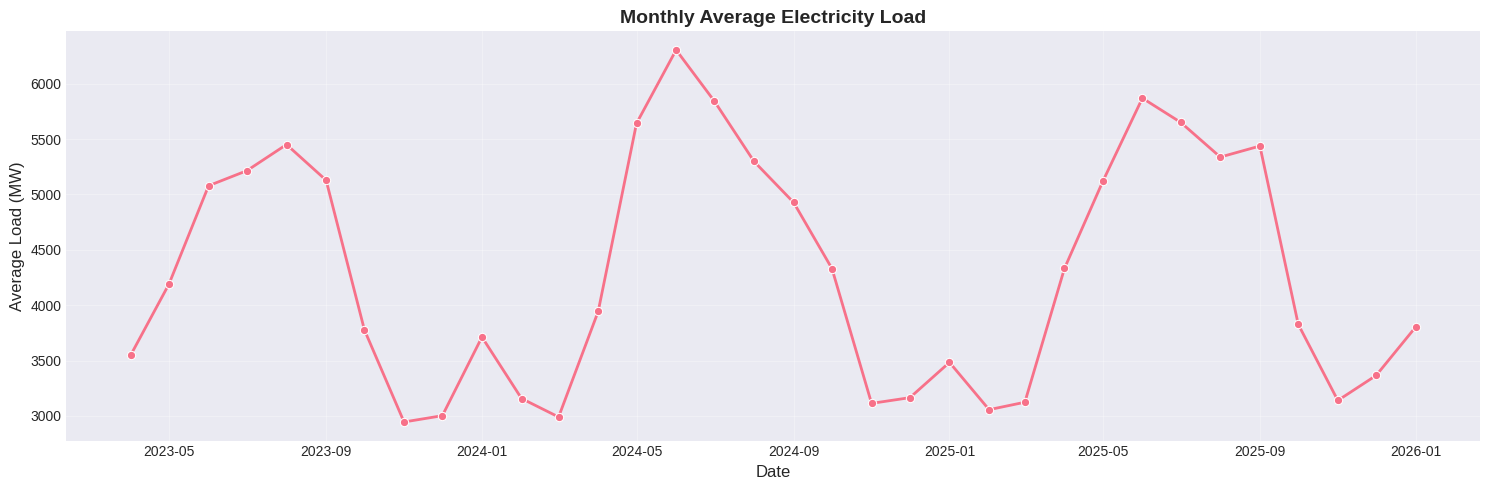

In [26]:
# monthly average load
monthly_avg = df_cpy.groupby([df_cpy.index.year, df_cpy.index.month])['load_MW'].mean()
monthly_avg.index.names = [None, None]
monthly_avg = monthly_avg.reset_index()
monthly_avg.columns = ['year', 'month', 'avg_load']

monthly_avg['date'] = pd.to_datetime(monthly_avg[['year', 'month']].assign(day=1))

fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(x='date', y='avg_load', data=monthly_avg, marker='o', linewidth=2)
ax.set_title('Monthly Average Electricity Load', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./plots/02_monthly_average.png', dpi=300, bbox_inches='tight')
plt.show()

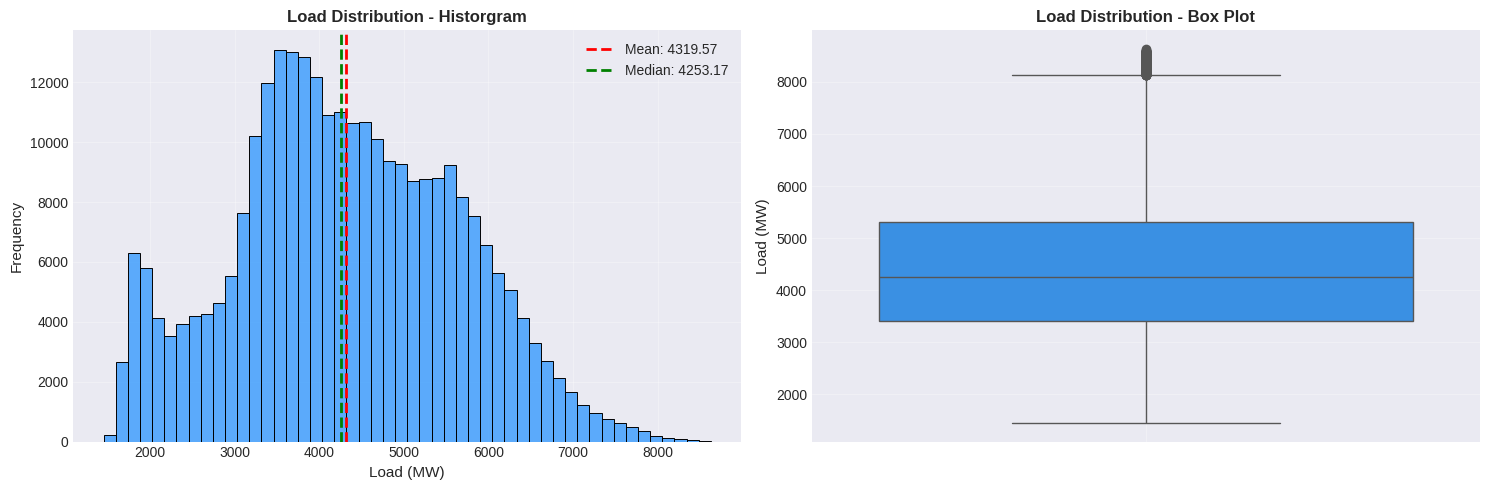

In [27]:
# distribution of load
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(x='load_MW', data=df_cpy, bins=50, edgecolor='black', alpha=0.7, ax=axs[0], color='Dodgerblue')
axs[0].axvline(df_cpy['load_MW'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_cpy['load_MW'].mean():.2f}")
axs[0].axvline(df_cpy['load_MW'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df_cpy['load_MW'].median():.2f}")
axs[0].set_title('Load Distribution - Historgram', fontsize=12, fontweight='bold')
axs[0].set_xlabel('Load (MW)', fontsize=11)
axs[0].set_ylabel('Frequency', fontsize=11)
axs[0].legend()
axs[0].grid(True, alpha=0.3)

sns.boxplot(y='load_MW', data=df_cpy, ax=axs[1], color='Dodgerblue')
axs[1].set_title('Load Distribution - Box Plot', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Load (MW)', fontsize=11)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/03_load_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

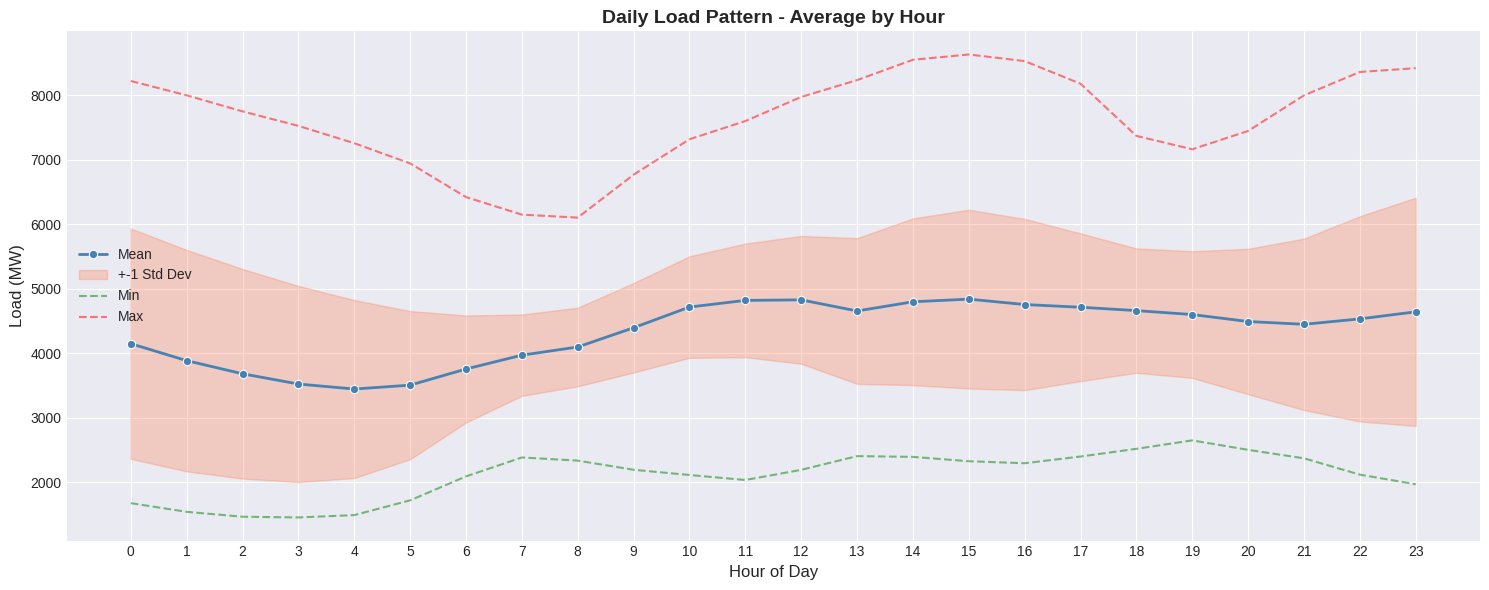

In [28]:
# hourly pattern (average load by hour of day)
hourly_pattern = df_cpy.groupby('hour')['load_MW'].agg(['mean', 'std', 'min', 'max'])

fig, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(x=hourly_pattern.index, y=hourly_pattern['mean'], marker='o', linewidth=2, label='Mean', color='steelblue', ax=ax)
ax.fill_between(hourly_pattern.index,
                hourly_pattern['mean'] - hourly_pattern['std'],
                hourly_pattern['mean'] + hourly_pattern['std'],
                alpha=0.3, label="+-1 Std Dev", color='Coral')
sns.lineplot(x=hourly_pattern.index, y=hourly_pattern['min'], linestyle='--', alpha=0.5, label='Min', color='green', ax=ax)
sns.lineplot(x=hourly_pattern.index, y=hourly_pattern['max'], linestyle='--', alpha=0.5, label='Max', color='red', ax=ax)

ax.set_title('Daily Load Pattern - Average by Hour', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Load (MW)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('./plots/04_hourly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

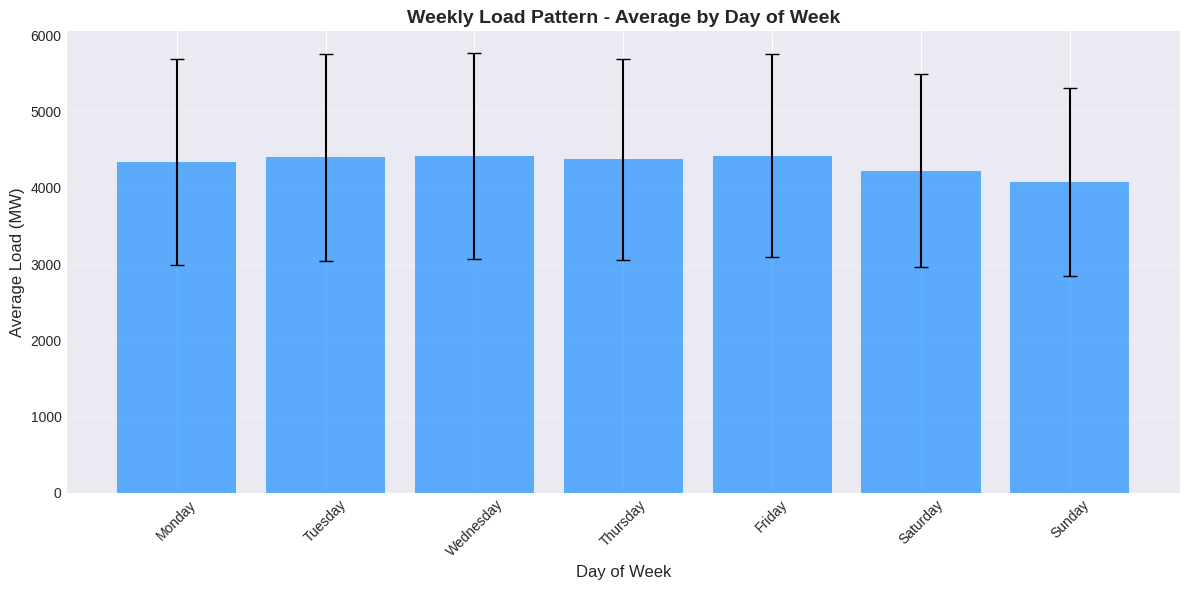

In [29]:
# weekly pattern
weekly_pattern = df_cpy.groupby('day_of_week')['load_MW'].agg(['mean', 'std'])
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x=np.arange(7), height=weekly_pattern["mean"].values,
       yerr=weekly_pattern["std"].values,
       capsize=5, alpha=0.7, color="dodgerblue")
ax.set_title('Weekly Load Pattern - Average by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names, rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./plots/05_weekly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

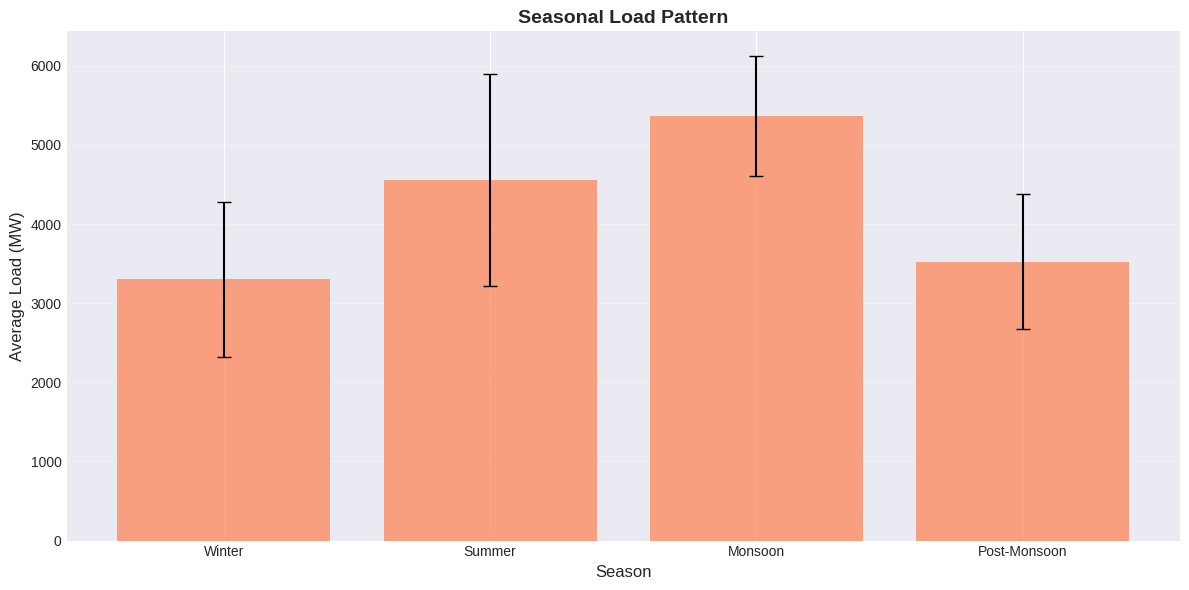

In [30]:
# seasonal pattern
seasonal_pattern = df_cpy.groupby('season')['load_MW'].agg(['mean', 'std', 'count'])
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
seasonal_pattern = seasonal_pattern.reindex(season_order)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x=seasonal_pattern.index, height=seasonal_pattern['mean'].values,
            yerr=seasonal_pattern['std'].values, capsize=5, alpha=0.7, color='coral')
ax.set_title('Seasonal Load Pattern', fontsize=14, fontweight='bold')
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./plots/06_seasonal_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

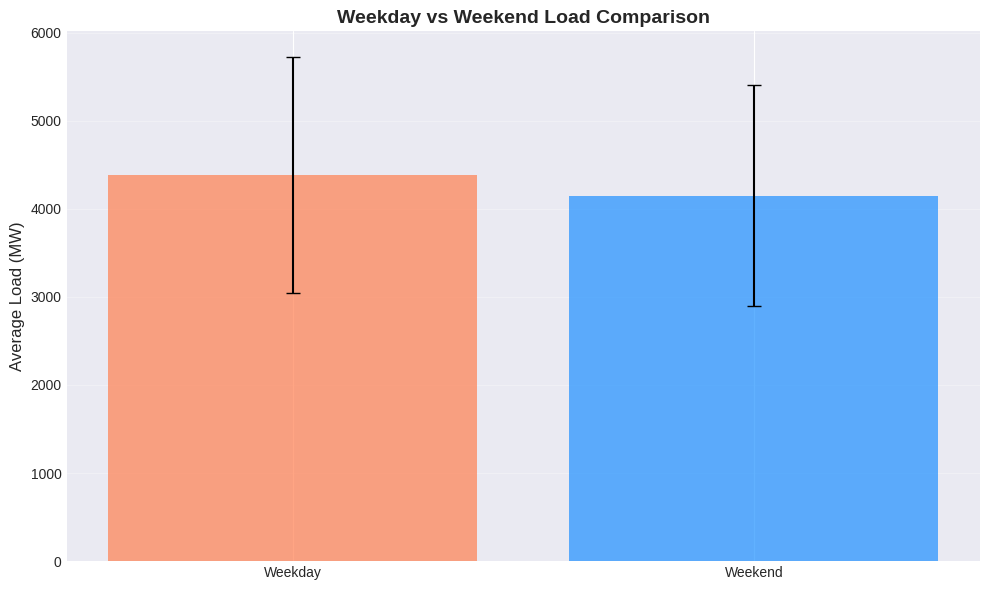

In [31]:
# weekday vs weekend
weekend_comparison = df_cpy.groupby('is_weekend')['load_MW'].agg(['mean', 'std'])
labels = ['Weekday', 'Weekend']

# yerr is headache
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=labels, height=weekend_comparison['mean'].values,
       yerr=weekend_comparison['std'].values, capsize=5, alpha=0.7, color=['coral', 'dodgerblue'])
ax.set_title('Weekday vs Weekend Load Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Load (MW)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./plots/07_weekday_vs_weekend.png', dpi=300, bbox_inches='tight')
plt.show()


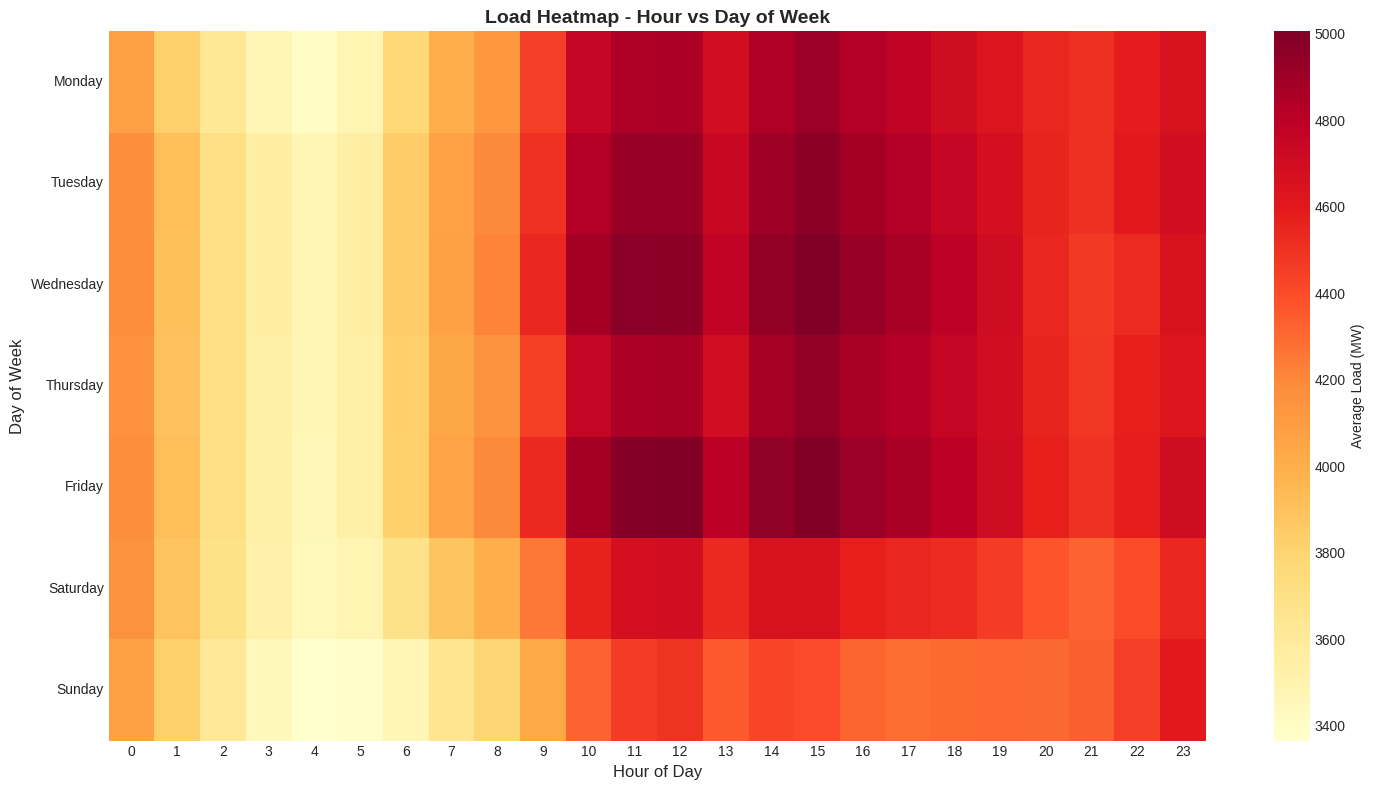

In [32]:
# hour vs day-of-week heatmap

pivot_hourly_daily = df_cpy.groupby(['day_of_week', 'hour'])['load_MW'].mean().unstack()

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot_hourly_daily, cmap='YlOrRd', annot=False, fmt='.0f',
            cbar_kws={'label': 'Average Load (MW)'}, ax=ax)
ax.set_title('Load Heatmap - Hour vs Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)
ax.set_yticklabels(day_names, rotation=0)
plt.tight_layout()
plt.savefig('./plots/08_heatmap_hour_day.png', dpi=300, bbox_inches='tight')
plt.show()

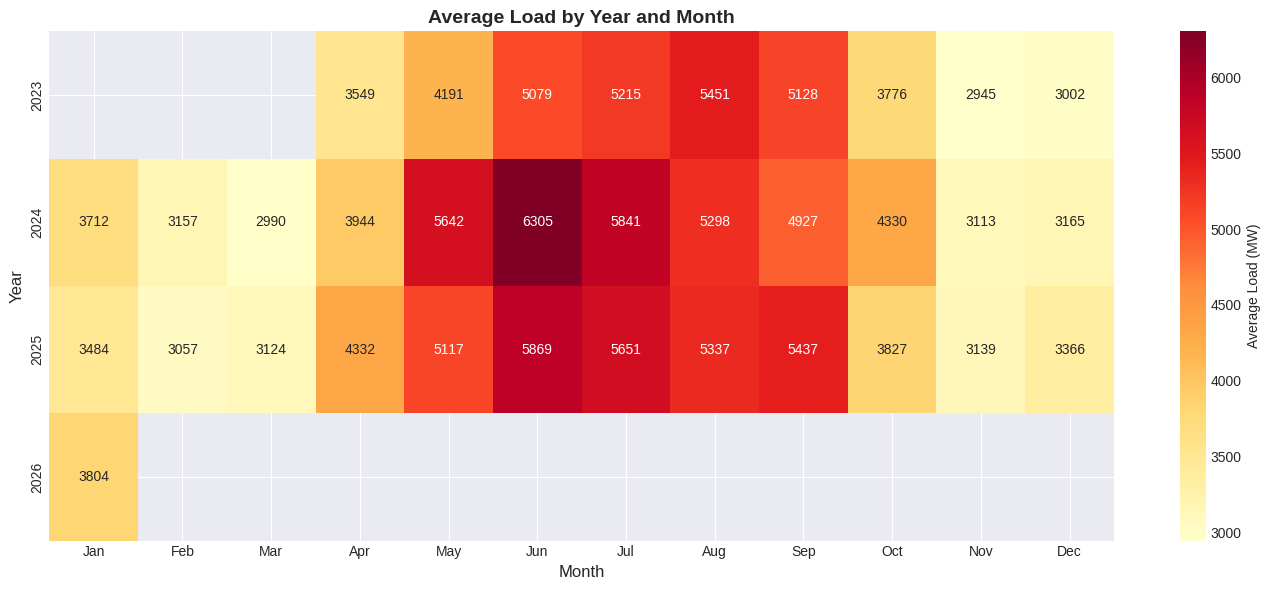

In [33]:
# monthly heatmap
pivot_monthly = df_cpy.groupby([df_cpy.index.year, df_cpy.index.month])['load_MW'].mean().unstack()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_monthly, cmap='YlOrRd', annot=True, fmt='.0f',
            cbar_kws={'label': 'Average Load (MW)'}, ax=ax)
ax.set_title('Average Load by Year and Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_xticklabels(month_names)
plt.tight_layout()
plt.savefig('./plots/09_heatmap_year_month.png', dpi=300, bbox_inches='tight')
plt.show()

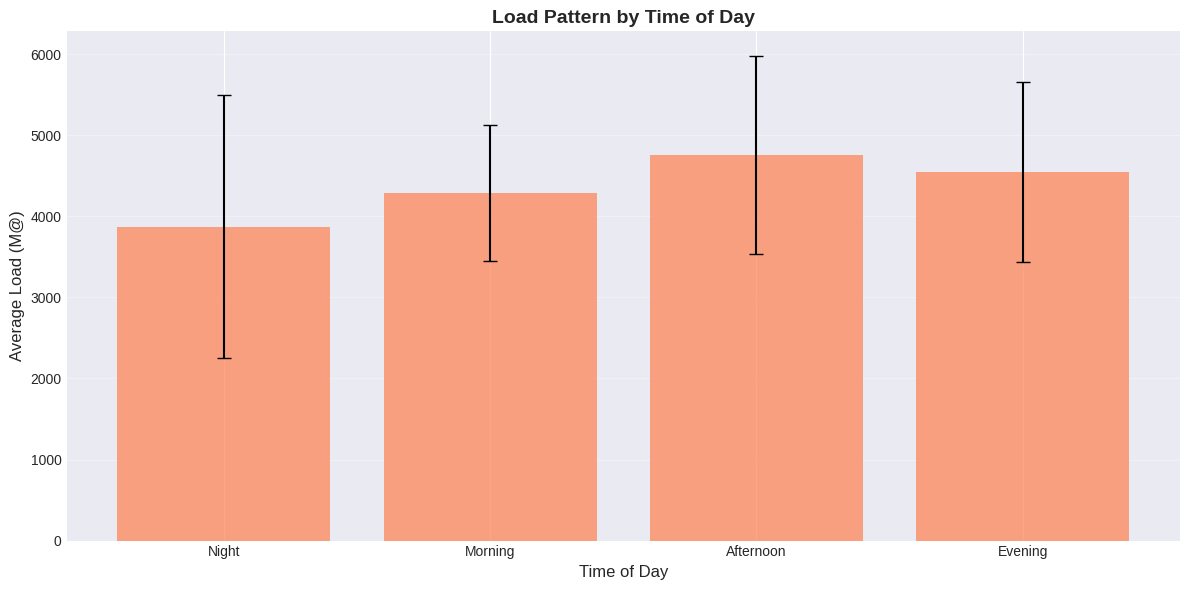

In [34]:
# load by time of day

time_of_day_pattern = df_cpy.groupby('time_of_day')['load_MW'].agg(['mean', 'std'])
time_order = ['Night', 'Morning', 'Afternoon', 'Evening']
time_of_day_pattern = time_of_day_pattern.reindex(time_order)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x=time_of_day_pattern.index, height=time_of_day_pattern['mean'].values,
            yerr=time_of_day_pattern['std'].values, capsize=5, alpha=0.7, color='Coral')
ax.set_title('Load Pattern by Time of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Time of Day', fontsize=12)
ax.set_ylabel('Average Load (M@)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('./plots/10_time_of_day_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Autocorrelation Analysis

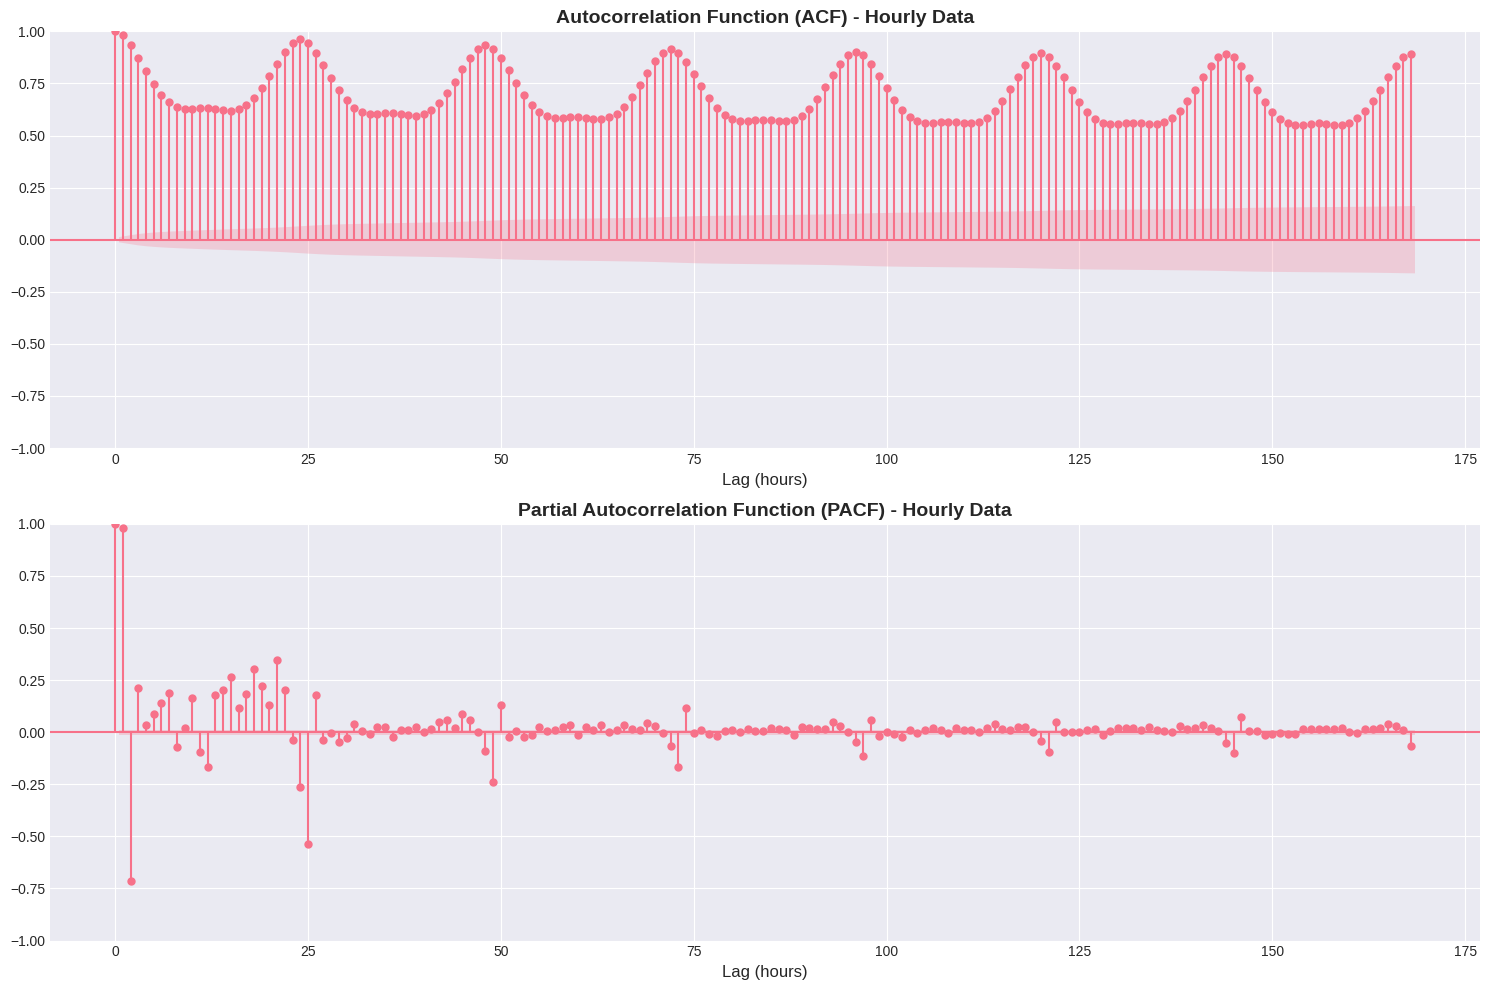

In [35]:
# hourly_data for speed
df_cp_cpy = df_cpy.copy()
df_cp_cpy = df_cp_cpy.fillna(method='ffill')
sample_data = df_cp_cpy['load_MW'].resample('1H').mean()

# try ffill & add is_missing column to first copied dataframe

fig, axs = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(sample_data, lags=168, ax=axs[0]) # 1 week of hourly data
axs[0].set_title('Autocorrelation Function (ACF) - Hourly Data', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Lag (hours)', fontsize=12)

plot_pacf(sample_data, lags=168, ax=axs[1])
axs[1].set_title('Partial Autocorrelation Function (PACF) - Hourly Data', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Lag (hours)', fontsize=12)

plt.tight_layout()
plt.savefig('./plots/11_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Trend & Seasonality Decomposition

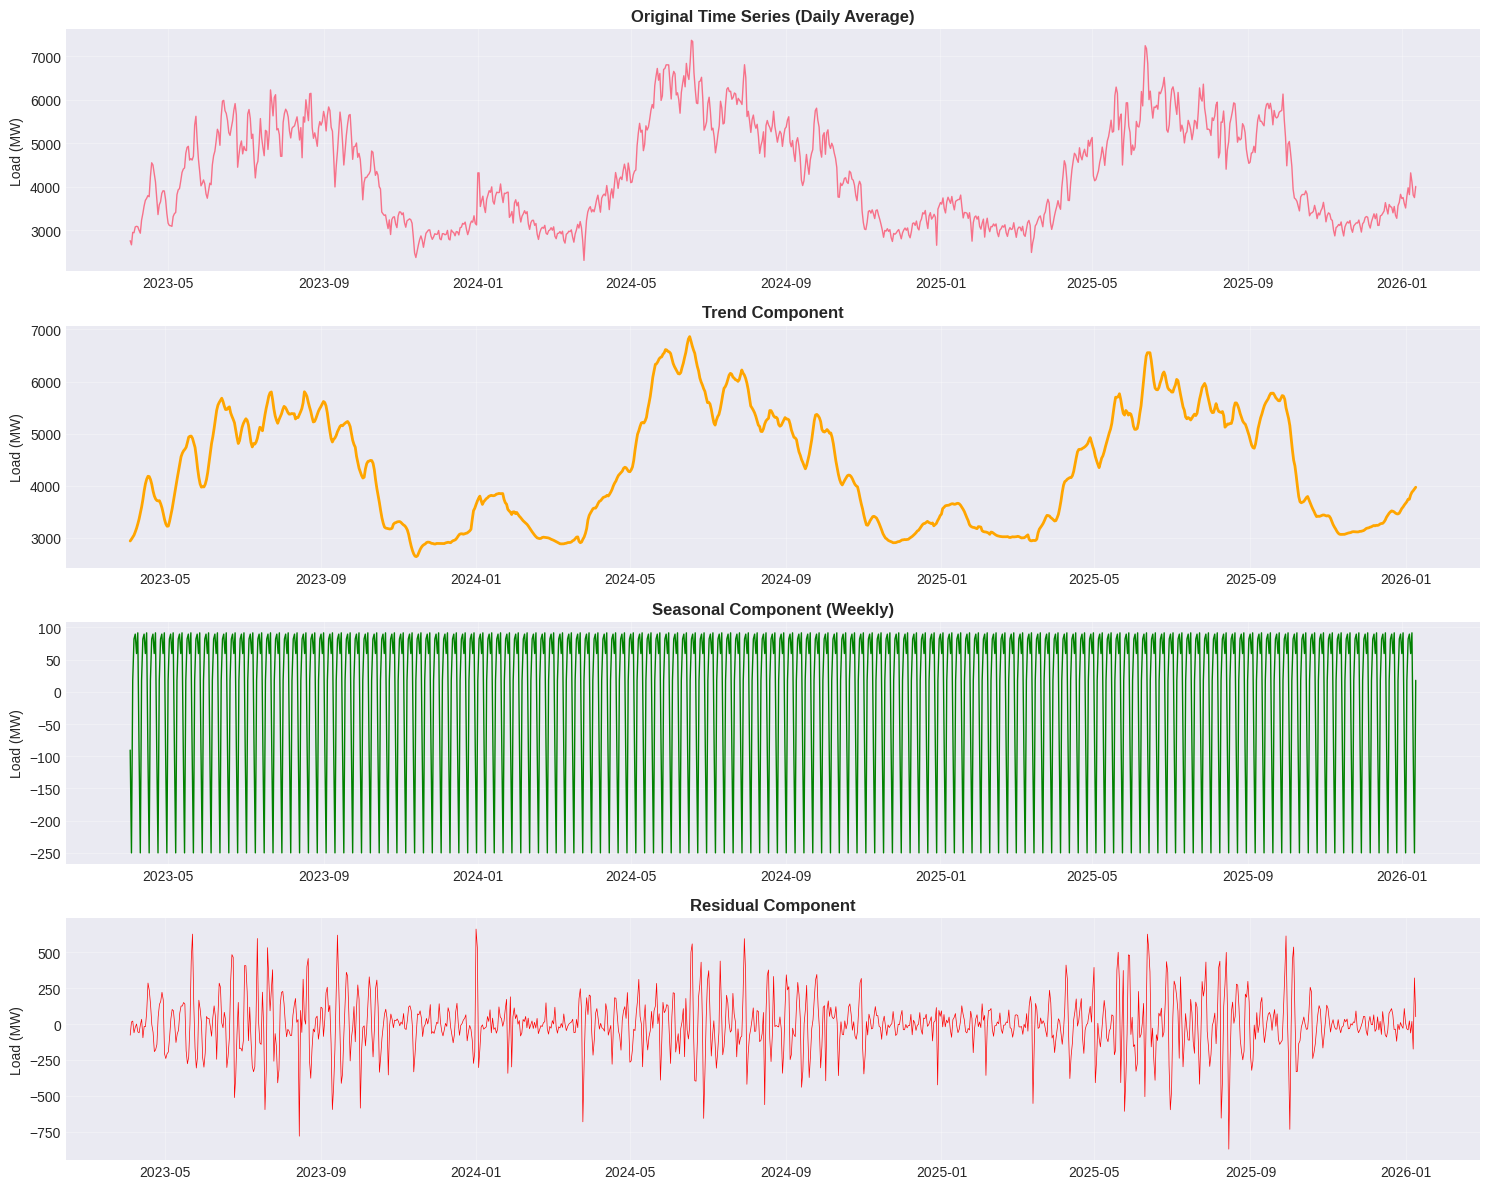

In [36]:
# using daily data
daily_data = df_cpy['load_MW'].resample('D').mean()
daily_data = daily_data.fillna(daily_data.mean())

decomposition = seasonal_decompose(daily_data, model='additive', period=7)

fig, axs = plt.subplots(4, 1, figsize=(15, 12))

axs[0].plot(decomposition.observed, linewidth=1)
axs[0].set_title('Original Time Series (Daily Average)', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Load (MW)')
axs[0].grid(True, alpha=0.3)

axs[1].plot(decomposition.trend, linewidth=2, color='orange')
axs[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Load (MW)')
axs[1].grid(True, alpha=0.3)

axs[2].plot(decomposition.seasonal, linewidth=1, color='green')
axs[2].set_title('Seasonal Component (Weekly)', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Load (MW)')
axs[2].grid(True, alpha=0.3)

axs[3].plot(decomposition.resid, linewidth=0.5, color='red')
axs[3].set_title('Residual Component', fontsize=12, fontweight='bold')
axs[3].set_ylabel('Load (MW)')
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/12_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()


# 8. Stationarity Test

In [37]:
adf_result = adfuller(sample_data.dropna())

print(f"ADF Test Results:")
print(f"  ADF Statistics: {adf_result[0]:.6f}")
print(f"  p-value: {adf_result[1]:.6f}")
print(f"  Critical Values:")
for key, value in adf_result[4].items():
  print(f"    {key}: {value:.3f}")

if adf_result[1] < 0.05:
  print("\n Result: Time series is STATIONARY (p<0.05)")
else:
  print("\n Result: Time series is NON-STATIONARY (p>=0.05)")
  print(" Consider differencing for forecasting models.")

ADF Test Results:
  ADF Statistics: -4.649083
  p-value: 0.000105
  Critical Values:
    1%: -3.431
    5%: -2.862
    10%: -2.567

 Result: Time series is STATIONARY (p<0.05)


# 9. Key Insights & Summary

In [38]:
peak_hour = hourly_pattern['mean'].idxmax()
min_hour = hourly_pattern['mean'].idxmin()
peak_day = weekly_pattern['mean'].idxmax()
peak_season = seasonal_pattern['mean'].idxmax()

print(f"\nTemporal Patterns:")
print(f"  Peak load hour: {peak_hour}:00 ({hourly_pattern['mean'][peak_hour]:.2f} MW)")
print(f"  Minimum load hour: {min_hour}:00 ({hourly_pattern['mean'][min_hour]:.2f} MW)")
print(f"  Peak load day: {day_names[peak_day]} ({weekly_pattern['mean'][peak_day]:.2f} MW)")
print(f"  Peak season: {peak_season} ({seasonal_pattern['mean'][peak_season]:.2f} MW)")

weekday_avg = df_cpy[df_cpy['is_weekend'] == 0]['load_MW'].mean()
weekend_avg = df_cpy[df_cpy['is_weekend'] == 1]['load_MW'].mean()
weekend_diff = ((weekend_avg - weekday_avg) / weekday_avg * 100)

print(f"\nWeekend Effect:")
print(f"  Weekday average: {weekday_avg:.2f} MW")
print(f"  Weekend average: {weekend_avg:.2f} MW")
print(f"  Difference: {weekend_diff:+.2f}%")

# variability analysis
print(f"\nVariability Analysis:")
print(f"  Hour with highest variability: {hourly_pattern['std'].idxmax()}:00 (Std: {hourly_pattern['std'].max():.2f} MW)")
print(f"  Hour with lowest variability: {hourly_pattern['std'].idxmin()}:00 (Std: {hourly_pattern['std'].min():.2f} MW)")

if df_cpy['year'].nunique() > 1:
    yearly_avg = df_cpy.groupby('year')['load_MW'].mean()
    print(f"\n\nYear-over-Year Comparison:")
    for year, avg in yearly_avg.items():
        print(f"  {year}: {avg:.2f} MW")


Temporal Patterns:
  Peak load hour: 15:00 (4836.72 MW)
  Minimum load hour: 4:00 (3442.08 MW)
  Peak load day: Friday (4419.59 MW)
  Peak season: Monsoon (5368.59 MW)

Weekend Effect:
  Weekday average: 4388.66 MW
  Weekend average: 4149.12 MW
  Difference: -5.46%

Variability Analysis:
  Hour with highest variability: 0:00 (Std: 1787.04 MW)
  Hour with lowest variability: 8:00 (Std: 609.99 MW)


Year-over-Year Comparison:
  2023: 4257.47 MW
  2024: 4384.08 MW
  2025: 4318.04 MW
  2026: 3803.81 MW


In [39]:
# index is needed
df_cpy.to_csv('./proc_df.csv')
print(f"Processed data saved!")

Processed data saved!


In [40]:
pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=b97ab47f9b68c9cdb2dae3a1fbcbd33a0416cf2f6804c64bf39c3a7da65aaaec
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [ ]:
import os
from fpdf import FPDF

def generate_final_report(df_processed, plot_dir='/content/plots/', output_filename='Delhi_Load_Final_Report.pdf'):
    # Basic checks to ensure directory exists
    if not os.path.exists(plot_dir):
        print(f"Error: {plot_dir} not found. Please run the visualization cells first.")
        return

    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)

    # Title Page
    pdf.add_page()
    pdf.set_font('Arial', 'B', 16)
    pdf.cell(0, 20, 'Delhi Electricity Load Infrastructure Analysis', 0, 1, 'C')

    pdf.set_font('Arial', '', 12)
    stats = df_processed['load_MW'].describe()
    pdf.cell(0, 10, f"Analysis Period Data Points: {len(df_processed):,}", 0, 1)
    pdf.cell(0, 10, f"Average Demand: {stats['mean']:.2f} MW", 0, 1)
    pdf.cell(0, 10, f"Maximum Recorded Peak: {stats['max']:.2f} MW", 0, 1)
    pdf.ln(10)

    # Fetch existing plots
    plot_files = sorted([f for f in os.listdir(plot_dir) if f.endswith('.png')])

    if not plot_files:
        print("No images found in the plots directory.")
        return

    # Append images to PDF
    for i, plot_file in enumerate(plot_files):
        pdf.add_page()
        pdf.set_font('Arial', 'I', 10)
        pdf.cell(0, 10, f"Figure {i+1}: {plot_file.replace('_', ' ').title()}", 0, 1)
        # Use absolute path to ensure fpdf finds the files
        img_path = os.path.join(plot_dir, plot_file)
        pdf.image(img_path, x=10, y=30, w=190)

    pdf.output(output_filename)
    print(f"Success! Report generated using existing plots: {output_filename}")

generate_final_report(df_cpy)